# Šesták–Berggren model: forward & inverse PINNs

The **Šesták–Berggren (SB)** equation is a flexible empirical rate law widely used in
solid-state reaction kinetics and thermal analysis. The conversion (or extent of
reaction) $y(t)\in[0,1]$ evolves as

$$\frac{dy}{dt} = k\,y^{m}\,(1-y)^{n},\qquad y(0)=y_0,$$

where $k>0$ is a rate constant and $(m,n)$ are reaction-order exponents that encode
the autocatalytic ($y^m$) and decelerating ($\,(1-y)^n$) parts of the mechanism.

This notebook does two things:

1. **Forward problem** — train a Physics-Informed Neural Network (PINN) to solve the
   SB ODE for *known* parameters, and validate it against a Runge–Kutta (RK4) reference.
2. **Inverse problem** — generate noisy synthetic observations from the RK4 solution and
   let a PINN *jointly* recover the network and the unknown ODE parameters, assessing how
   well the architecture identifies $(m,n,k)$.


## Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve()
while not (ROOT / "src").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError(f"Cannot find project root from {Path().resolve()}")
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")

from src.PINNs import PINN, PINNConfig, TrainingConfig
from src.numerical_solvers import rk4_solve

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

# Training a PINN requires second-order autograd (a gradient of the ODE residual,
# which itself contains d/dt of the network). Apple's MPS backend is unreliable for
# these grad-of-grad graphs and yields a degenerate forward solve, so we pin to CPU.
# The networks here are tiny (width 64), so CPU is more than fast enough.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

ROOT = /Users/marcogalliani/Projects/PINNs-and-spectral-bias
Device: cpu


## Configuration

We pick a representative SB regime. The initial condition is taken slightly above zero:
with $y_0=0$ and $m>0$ the right-hand side vanishes and the conversion never ignites, so a
small nucleation value $y_0>0$ is physically and numerically necessary.

In [2]:
from argparse import Namespace

opt = Namespace()

# --- True Šesták–Berggren parameters (ground truth) ---
opt.m_true = 0.7      # autocatalytic exponent
opt.n_true = 1.3      # decelerating exponent
opt.k_true = 2.5      # rate constant
opt.y0     = 0.05     # nucleation initial condition
opt.T      = 5.0      # time horizon

# --- Discretisation / evaluation grid ---
opt.N_POINTS = 400
t_eval = np.linspace(0.0, opt.T, opt.N_POINTS).astype(np.float32)

# --- Numerical guards for non-integer powers of a possibly out-of-range base ---
EPS = 1e-6

## The Šesták–Berggren ODE

We wrap the right-hand side in a small class exposing both a NumPy version (for the RK4
reference) and a Torch version (for the PINN residual). Because the exponents $m,n$ are
generally non-integer, the base must stay in $[0,1]$ — otherwise `y**m` is NaN for a
negative base. During training the network can transiently leave $[0,1]$, so we clamp the
base inside the rate law.

In [3]:
class SestakBerggren:
    '''dy/dt = k * y**m * (1 - y)**n.'''

    def __init__(self, m, n, k):
        self.m, self.n, self.k = float(m), float(n), float(k)

    def rhs_np(self, t, z):
        y = min(max(z[0], EPS), 1.0 - EPS)
        return [self.k * y**self.m * (1.0 - y)**self.n]

    def rhs_torch(self, t, z):
        yc = torch.clamp(z, EPS, 1.0 - EPS)
        return self.k * yc**self.m * (1.0 - yc)**self.n


ode = SestakBerggren(opt.m_true, opt.n_true, opt.k_true)

### Runge–Kutta reference solution

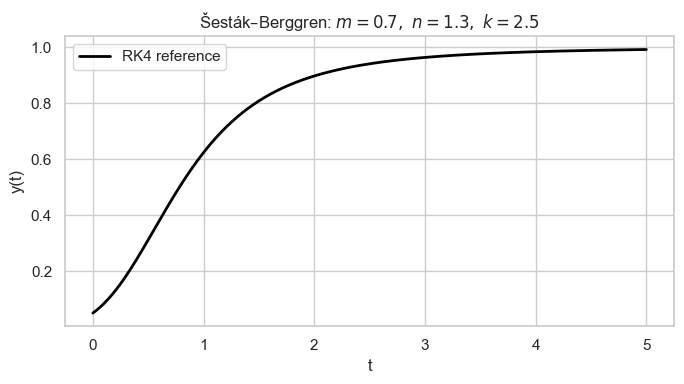

y range: [0.0500, 0.9915]


In [4]:
y_ref = rk4_solve(ode.rhs_np, [opt.y0], t_eval)   # (N, 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_eval, y_ref[:, 0], color="black", lw=2, label="RK4 reference")
ax.set_xlabel("t"); ax.set_ylabel("y(t)")
ax.set_title(rf"Šesták–Berggren: $m={opt.m_true},\ n={opt.n_true},\ k={opt.k_true}$")
ax.legend()
fig.tight_layout()
plt.show()

print(f"y range: [{y_ref.min():.4f}, {y_ref.max():.4f}]")

## Forward problem — PINN solution

For the forward problem the parameters are *known*. We use the **hard initial condition**
parametrisation $\;y(t) = y_0 + t\,\mathcal{N}_\theta(t)\;$ so that $y(0)=y_0$ holds
exactly and the loss reduces to the physics residual alone.

**A pitfall specific to the SB model.** Since $\dot y = k\,y^{m}(1-y)^{n}$ vanishes at
$y=0$, the constant $y\equiv 0$ is an (unstable) equilibrium with essentially zero
residual — it competes with the true solution as a loss minimiser. A residual-only PINN
trained on the whole interval at once therefore *collapses onto this spurious zero branch*
for many random initialisations. We avoid it with a **causal time-marching curriculum**:
the horizon is grown progressively while reusing the same network, so the solution is
constructed forward from its positive initial slope and never sees the trivial branch as a
shortcut.

In [5]:
fwd_net = PINN(PINNConfig(n_vars=1, width=64, depth=4)).to(DEVICE)

# Grow the time horizon progressively, reusing the same network each time.
T_WINDOWS = [0.5, 1.0, 2.0, 3.0, 4.0, opt.T]

for Tw in T_WINDOWS:
    fwd_cfg = TrainingConfig(
        n_iter=3_000, n_colloc=256, lr=2e-3, hard_ic=True,
        lr_decay=0.9998, rec_frq=3_000, verbose=False,
    )
    fwd_frames = fwd_net.fit(
        ode.rhs_torch, (0.0, Tw), [opt.y0],
        tr_cfg=fwd_cfg, t_eval_np=t_eval,
    )
    print(f"  horizon [0, {Tw:>3}]  ->  final residual loss {fwd_frames[-1].loss:.2e}")

  horizon [0, 0.5]  ->  final residual loss 6.63e-08
  horizon [0, 1.0]  ->  final residual loss 8.30e-07
  horizon [0, 2.0]  ->  final residual loss 1.08e-06
  horizon [0, 3.0]  ->  final residual loss 1.76e-05
  horizon [0, 4.0]  ->  final residual loss 1.48e-07
  horizon [0, 5.0]  ->  final residual loss 8.47e-08


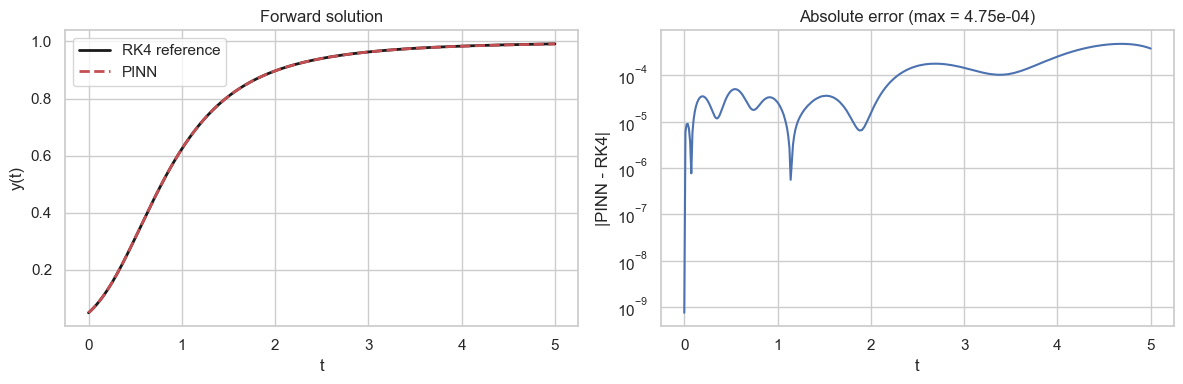

In [6]:
# Evaluate the trained forward PINN (apply the same hard-IC transform used in training)
with torch.no_grad():
    t_t = torch.tensor(t_eval, dtype=torch.float32, device=DEVICE).view(-1, 1)
    y_pinn = (opt.y0 + t_t * fwd_net(t_t)).cpu().numpy()

abs_err = np.abs(y_pinn[:, 0] - y_ref[:, 0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_eval, y_ref[:, 0], "k-", lw=2, label="RK4 reference")
axes[0].plot(t_eval, y_pinn[:, 0], "r--", lw=2, label="PINN")
axes[0].set_xlabel("t"); axes[0].set_ylabel("y(t)"); axes[0].legend()
axes[0].set_title("Forward solution")

axes[1].semilogy(t_eval, abs_err + 1e-16, "b-")
axes[1].set_xlabel("t"); axes[1].set_ylabel("|PINN - RK4|")
axes[1].set_title(f"Absolute error (max = {abs_err.max():.2e})")
fig.tight_layout()
plt.show()

## Inverse problem — parameter estimation

Now we hide the parameters. From the RK4 trajectory we draw a handful of **noisy
observations** $\{(t_i, y_i^{\text{obs}})\}$ and ask: can a PINN recover $(m,n)$ (and $k$)?

The idea is to treat the unknown ODE parameters as **additional trainable variables** that
are optimised jointly with the network weights. The loss combines

$$\mathcal{L} = \underbrace{\frac{1}{N_c}\sum_j \Big(\dot y_\theta(t_j) - k\,y_\theta^{m}(1-y_\theta)^{n}\Big)^2}_{\text{physics residual}}
\;+\; \lambda\,\underbrace{\frac{1}{N_d}\sum_i \big(y_\theta(t_i) - y_i^{\text{obs}}\big)^2}_{\text{data misfit}} .$$

The data term pins the network to the observations; the physics term forces the network
onto the ODE manifold and, through its dependence on $(m,n,k)$, back-propagates a gradient
into the parameters. We parametrise each parameter as $\exp(\cdot)$ to keep it positive.

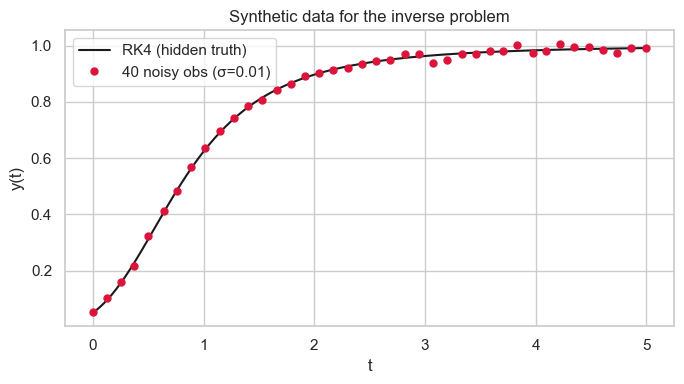

In [7]:
# --- Generate noisy observations from the RK4 reference ---
rng = np.random.default_rng(1)
N_DATA   = 40
NOISE_SD = 0.01

idx_data = np.linspace(0, len(t_eval) - 1, N_DATA).astype(int)
t_data   = t_eval[idx_data]
y_data   = y_ref[idx_data, 0] + NOISE_SD * rng.standard_normal(N_DATA)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_eval, y_ref[:, 0], "k-", lw=1.5, label="RK4 (hidden truth)")
ax.plot(t_data, y_data, "o", color="crimson", ms=5, label=f"{N_DATA} noisy obs (σ={NOISE_SD})")
ax.set_xlabel("t"); ax.set_ylabel("y(t)"); ax.legend()
ax.set_title("Synthetic data for the inverse problem")
fig.tight_layout()
plt.show()

### Joint training routine

In [8]:
def solve_inverse(
    t_data, y_data, T, *,
    estimate_k=True, k_fixed=None,
    init=(1.0, 1.0, 1.0),
    n_iter=12_000, n_colloc=256, lr=2e-3, lr_decay=0.9998,
    data_weight=50.0, rec_frq=200, seed=0, verbose=True,
):
    '''Jointly fit a PINN and the SB parameters (m, n, [k]) to noisy data.

    Returns (net, history) where history is a list of dicts with the parameter
    trajectory recorded every `rec_frq` iterations.
    '''
    torch.manual_seed(seed)
    net = PINN(PINNConfig(n_vars=1, width=64, depth=4)).to(DEVICE)

    t_d = torch.tensor(t_data, dtype=torch.float32, device=DEVICE).view(-1, 1)
    y_d = torch.tensor(y_data, dtype=torch.float32, device=DEVICE).view(-1, 1)

    m0, n0, k0 = init
    log_m = torch.tensor([np.log(m0)], dtype=torch.float32, device=DEVICE, requires_grad=True)
    log_n = torch.tensor([np.log(n0)], dtype=torch.float32, device=DEVICE, requires_grad=True)
    params = list(net.parameters()) + [log_m, log_n]
    if estimate_k:
        log_k = torch.tensor([np.log(k0)], dtype=torch.float32, device=DEVICE, requires_grad=True)
        params = params + [log_k]

    opt = torch.optim.Adam(params, lr=lr)
    sch = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=lr_decay)

    history = []
    for it in range(n_iter + 1):
        opt.zero_grad()

        t_col = (torch.rand(n_colloc, 1, device=DEVICE) * T).requires_grad_(True)
        y = net(t_col)
        dy = torch.autograd.grad(y.sum(), t_col, create_graph=True)[0]

        m, n = torch.exp(log_m), torch.exp(log_n)
        k = torch.exp(log_k) if estimate_k else torch.tensor(k_fixed, dtype=torch.float32, device=DEVICE)
        yc = torch.clamp(y, EPS, 1.0 - EPS)

        phys = ((dy - k * yc**m * (1.0 - yc)**n) ** 2).mean()
        data = ((net(t_d) - y_d) ** 2).mean()
        loss = phys + data_weight * data

        loss.backward()
        opt.step()
        sch.step()

        if it % rec_frq == 0:
            rec = dict(iter=it, loss=loss.item(), phys=phys.item(), data=data.item(),
                       m=m.item(), n=n.item(), k=k.item())
            history.append(rec)
            if verbose and it % max(1, n_iter // 6) == 0:
                print(f"  iter {it:6d} | loss {loss.item():.3e} "
                      f"| phys {phys.item():.2e} | data {data.item():.2e} "
                      f"| m {m.item():.3f} n {n.item():.3f} k {k.item():.3f}")

    net.eval()
    return net, history

### Case 1 — estimate $(m, n)$ with a known rate constant $k$

A common experimental situation: the rate constant has been calibrated separately and only
the reaction orders are unknown. Starting both exponents from $1.0$, the PINN should
recover the true $(m,n)$.

In [9]:
inv_net_mn, hist_mn = solve_inverse(
    t_data, y_data, opt.T,
    estimate_k=False, k_fixed=opt.k_true,
    init=(1.0, 1.0, opt.k_true),
    seed=1,
)

m_hat = hist_mn[-1]["m"]; n_hat = hist_mn[-1]["n"]
print("\n--- Recovered parameters (k known) ---")
print(f"  m: true {opt.m_true:.3f}  |  estimated {m_hat:.3f}  "
      f"(rel. err {abs(m_hat-opt.m_true)/opt.m_true:.1%})")
print(f"  n: true {opt.n_true:.3f}  |  estimated {n_hat:.3f}  "
      f"(rel. err {abs(n_hat-opt.n_true)/opt.n_true:.1%})")

  iter      0 | loss 2.572e+01 | phys 7.06e-02 | data 5.13e-01 | m 1.000 n 1.000 k 2.500
  iter   2000 | loss 4.237e-03 | phys 7.27e-05 | data 8.33e-05 | m 0.707 n 1.301 k 2.500
  iter   4000 | loss 4.150e-03 | phys 3.11e-05 | data 8.24e-05 | m 0.708 n 1.301 k 2.500
  iter   6000 | loss 4.129e-03 | phys 2.62e-05 | data 8.21e-05 | m 0.707 n 1.301 k 2.500
  iter   8000 | loss 4.096e-03 | phys 2.40e-05 | data 8.14e-05 | m 0.708 n 1.300 k 2.500
  iter  10000 | loss 4.086e-03 | phys 2.79e-05 | data 8.12e-05 | m 0.707 n 1.301 k 2.500
  iter  12000 | loss 4.067e-03 | phys 4.04e-05 | data 8.05e-05 | m 0.707 n 1.301 k 2.500

--- Recovered parameters (k known) ---
  m: true 0.700  |  estimated 0.707  (rel. err 1.0%)
  n: true 1.300  |  estimated 1.301  (rel. err 0.1%)


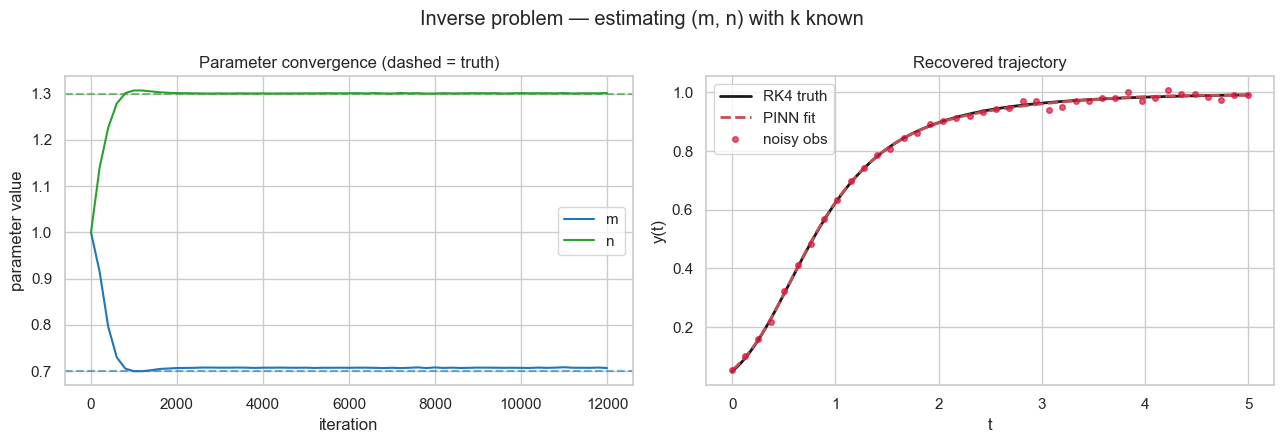

In [10]:
def plot_inverse(net, history, title, estimate_k):
    its = [h["iter"] for h in history]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # (a) parameter convergence
    ax = axes[0]
    ax.plot(its, [h["m"] for h in history], label="m", color="tab:blue")
    ax.plot(its, [h["n"] for h in history], label="n", color="tab:green")
    ax.axhline(opt.m_true, ls="--", color="tab:blue",  alpha=0.6)
    ax.axhline(opt.n_true, ls="--", color="tab:green", alpha=0.6)
    if estimate_k:
        ax.plot(its, [h["k"] for h in history], label="k", color="tab:red")
        ax.axhline(opt.k_true, ls="--", color="tab:red", alpha=0.6)
    ax.set_xlabel("iteration"); ax.set_ylabel("parameter value")
    ax.set_title("Parameter convergence (dashed = truth)"); ax.legend()

    # (b) fitted solution vs truth and data
    ax = axes[1]
    with torch.no_grad():
        t_t = torch.tensor(t_eval, dtype=torch.float32, device=DEVICE).view(-1, 1)
        y_fit = net(t_t).cpu().numpy()[:, 0]
    ax.plot(t_eval, y_ref[:, 0], "k-", lw=2, label="RK4 truth")
    ax.plot(t_eval, y_fit, "r--", lw=2, label="PINN fit")
    ax.plot(t_data, y_data, "o", color="crimson", ms=4, alpha=0.7, label="noisy obs")
    ax.set_xlabel("t"); ax.set_ylabel("y(t)"); ax.legend()
    ax.set_title("Recovered trajectory")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


plot_inverse(inv_net_mn, hist_mn, "Inverse problem — estimating (m, n) with k known",
             estimate_k=False)

### Case 2 — estimate all three $(m, n, k)$

When the rate constant is *also* unknown the problem becomes substantially harder. The SB
right-hand side enters the dynamics only through the **product** $k\,y^{m}(1-y)^{n}$, so
different $(m,n,k)$ triples can reproduce essentially the same trajectory. This is a
genuine **weak-identifiability** issue, not a training artefact: the data misfit drops to
the noise floor while the parameters settle on a different point of the level set.

  iter      0 | loss 2.566e+01 | phys 9.83e-03 | data 5.13e-01 | m 1.000 n 1.000 k 1.000
  iter   2000 | loss 4.545e-03 | phys 2.51e-04 | data 8.59e-05 | m 0.554 n 1.157 k 1.942
  iter   4000 | loss 4.160e-03 | phys 3.56e-05 | data 8.25e-05 | m 0.702 n 1.297 k 2.484
  iter   6000 | loss 4.104e-03 | phys 1.10e-05 | data 8.19e-05 | m 0.759 n 1.357 k 2.739
  iter   8000 | loss 4.075e-03 | phys 1.12e-05 | data 8.13e-05 | m 0.766 n 1.363 k 2.768
  iter  10000 | loss 4.054e-03 | phys 1.73e-05 | data 8.07e-05 | m 0.766 n 1.364 k 2.770
  iter  12000 | loss 4.038e-03 | phys 2.57e-05 | data 8.02e-05 | m 0.766 n 1.365 k 2.772

--- Recovered parameters (m, n, k all unknown) ---
  m: true 0.700  |  estimated 0.766
  n: true 1.300  |  estimated 1.365
  k: true 2.500  |  estimated 2.772
  final data misfit (MSE): 8.02e-05  (noise variance ≈ 1e-04)


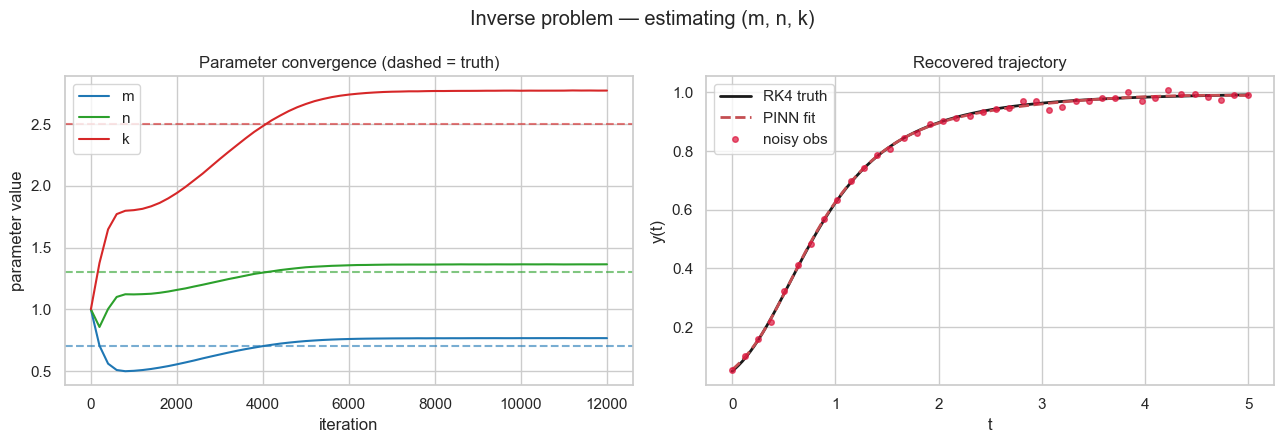

In [11]:
inv_net_all, hist_all = solve_inverse(
    t_data, y_data, opt.T,
    estimate_k=True,
    init=(1.0, 1.0, 1.0),
    seed=1,
)

print("\n--- Recovered parameters (m, n, k all unknown) ---")
print(f"  m: true {opt.m_true:.3f}  |  estimated {hist_all[-1]['m']:.3f}")
print(f"  n: true {opt.n_true:.3f}  |  estimated {hist_all[-1]['n']:.3f}")
print(f"  k: true {opt.k_true:.3f}  |  estimated {hist_all[-1]['k']:.3f}")
print(f"  final data misfit (MSE): {hist_all[-1]['data']:.2e}  "
      f"(noise variance ≈ {NOISE_SD**2:.0e})")

plot_inverse(inv_net_all, hist_all, "Inverse problem — estimating (m, n, k)",
             estimate_k=True)

## Breaking the degeneracy — an Arrhenius temperature sweep

Case 2 showed that $(m,n,k)$ cannot be separated from a *single* trajectory. The classic
remedy in chemical kinetics is to observe the reaction at **several temperatures** and tie
the rate constant to temperature through the **Arrhenius law**

$$k(T) = A\,\exp\!\Big(-\frac{E_a}{R\,T}\Big),$$

with pre-exponential factor $A$, activation energy $E_a$, and gas constant
$R=8.314\;\mathrm{J\,mol^{-1}K^{-1}}$. Each temperature yields a different $k(T)$ and hence a
different trajectory, while $A,E_a,m,n$ are **shared** across all of them. We generate data at $T\in\{5,20,32,37\}$ and then solve the joint inverse problem for
$(A,E_a,m,n)$.

A_true = 1.593e+09    Ea_true = 50000 J/mol    T_ref = 296.65 K
  T =    5 °C  ->  k(T) = 0.649
  T =   20 °C  ->  k(T) = 1.963
  T =   32 °C  ->  k(T) = 4.397
  T =   37 °C  ->  k(T) = 6.042


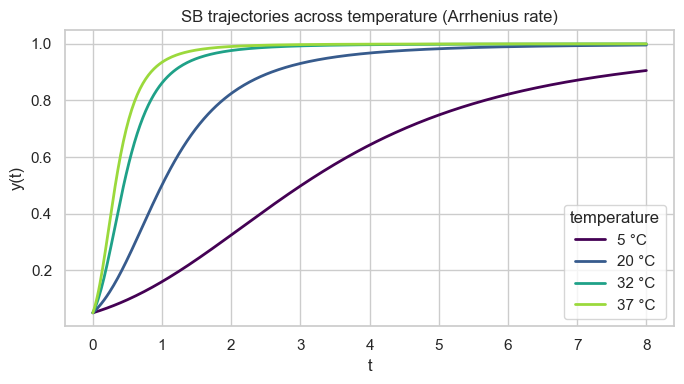

In [12]:
R_GAS = 8.314                          # J / (mol K)
T_CELSIUS = np.array([5.0, 20.0, 32.0, 37.0])
T_KELVIN  = T_CELSIUS + 273.15
T_REF     = float(T_KELVIN.mean())     # reference temperature used for centring

# True kinetics: reuse (m, n); fix A through the rate at the reference temperature
opt.Ea_true = 50_000.0                 # activation energy [J/mol]
k_ref_true  = 2.5                      # true rate constant at T_REF
opt.A_true  = k_ref_true * np.exp(opt.Ea_true / (R_GAS * T_REF))
opt.T_h     = 8.0                      # longer horizon so the cold (slow) run completes

def arrhenius(T, A, Ea):
    return A * np.exp(-Ea / (R_GAS * T))

# Generate one RK4 trajectory per temperature
t_grid = np.linspace(0.0, opt.T_h, 400).astype(np.float32)
traj = {}
for Tc, Tk in zip(T_CELSIUS, T_KELVIN):
    ode_T = SestakBerggren(opt.m_true, opt.n_true, arrhenius(Tk, opt.A_true, opt.Ea_true))
    traj[Tc] = rk4_solve(ode_T.rhs_np, [opt.y0], t_grid)[:, 0]

print(f"A_true = {opt.A_true:.3e}    Ea_true = {opt.Ea_true:.0f} J/mol    T_ref = {T_REF:.2f} K")
for Tc, Tk in zip(T_CELSIUS, T_KELVIN):
    print(f"  T = {Tc:>4.0f} °C  ->  k(T) = {arrhenius(Tk, opt.A_true, opt.Ea_true):.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
colors = plt.cm.viridis(np.linspace(0.0, 0.85, len(T_CELSIUS)))
for c, Tc in zip(colors, T_CELSIUS):
    ax.plot(t_grid, traj[Tc], lw=2, color=c, label=f"{Tc:.0f} °C")
ax.set_xlabel("t"); ax.set_ylabel("y(t)"); ax.legend(title="temperature")
ax.set_title("SB trajectories across temperature (Arrhenius rate)")
fig.tight_layout(); plt.show()

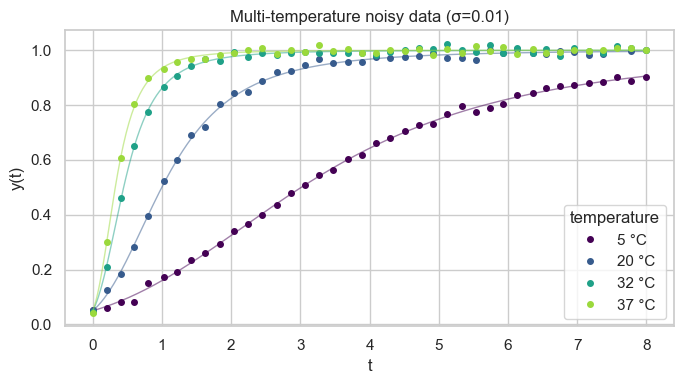

In [13]:
# Noisy observations for every temperature
rng_T    = np.random.default_rng(2)
N_DATA_T = 40
idx_T    = np.linspace(0, len(t_grid) - 1, N_DATA_T).astype(int)

datasets = {}                          # Tc -> (t_obs, y_obs)
for Tc in T_CELSIUS:
    y_obs = traj[Tc][idx_T] + NOISE_SD * rng_T.standard_normal(N_DATA_T)
    datasets[Tc] = (t_grid[idx_T], y_obs)

fig, ax = plt.subplots(figsize=(7, 4))
for c, Tc in zip(colors, T_CELSIUS):
    ax.plot(t_grid, traj[Tc], "-", color=c, lw=1, alpha=0.5)
    ax.plot(*datasets[Tc], "o", color=c, ms=4, label=f"{Tc:.0f} °C")
ax.set_xlabel("t"); ax.set_ylabel("y(t)"); ax.legend(title="temperature")
ax.set_title(f"Multi-temperature noisy data (σ={NOISE_SD})")
fig.tight_layout(); plt.show()

### Joint training routine

Each temperature gets its **own** solution network $y_\theta^{(T)}(t)$ (it is a distinct
experiment), but all networks share the four kinetic unknowns. For a well-conditioned
optimisation we estimate the rate at the reference temperature, $k_{\mathrm{ref}}$, together
with $E_a$, using the **centred** Arrhenius form

$$k(T) = k_{\mathrm{ref}}\,\exp\!\Big(-\tfrac{E_a}{R}\big(\tfrac{1}{T}-\tfrac{1}{T_{\mathrm{ref}}}\big)\Big),
\qquad A = k_{\mathrm{ref}}\,\exp\!\Big(\tfrac{E_a}{R\,T_{\mathrm{ref}}}\Big).$$

Centring at $T_{\mathrm{ref}}$ keeps the trainable scalars $O(1)$ and largely decorrelates
$k_{\mathrm{ref}}$ from $E_a$ (in contrast to the raw $(A,E_a)$ pair, which is strongly
correlated — see the next section). The kinetic scalars get a larger learning rate than the
network weights.

In [14]:
def solve_inverse_arrhenius(
    datasets, temps_K, T_ref, T_h, *,
    Ea_init=40_000.0, kref_init=1.0, mn_init=(1.0, 1.0),
    n_iter=12_000, n_colloc=128, lr_net=2e-3, lr_kin=2e-2, lr_decay=0.9999,
    data_weight=50.0, rec_frq=200, seed=0, verbose=True,
):
    """Joint inverse over several temperatures.

    One PINN per trajectory; shared kinetic unknowns (k_ref, Ea, m, n) estimated in
    the centred Arrhenius parametrisation. Returns (nets, history, estimates) where
    estimates is a dict with the recovered A, Ea, m, n (and k_ref).
    """
    torch.manual_seed(seed)
    temps = list(datasets.keys())
    nets = [PINN(PINNConfig(n_vars=1, width=64, depth=4)).to(DEVICE) for _ in temps]

    EA_SCALE = 1e4                                   # so the trainable Ea scalar is O(1)
    log_kref = torch.tensor([np.log(kref_init)], dtype=torch.float32, device=DEVICE, requires_grad=True)
    s_ea     = torch.tensor([Ea_init / EA_SCALE],  dtype=torch.float32, device=DEVICE, requires_grad=True)
    log_m    = torch.tensor([np.log(mn_init[0])],  dtype=torch.float32, device=DEVICE, requires_grad=True)
    log_n    = torch.tensor([np.log(mn_init[1])],  dtype=torch.float32, device=DEVICE, requires_grad=True)
    kin = [log_kref, s_ea, log_m, log_n]

    net_params = [p for net in nets for p in net.parameters()]
    optimizer = torch.optim.Adam([
        {"params": net_params, "lr": lr_net},
        {"params": kin,        "lr": lr_kin},
    ])
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)

    Tk   = torch.tensor([temps_K[Tc] for Tc in temps], dtype=torch.float32, device=DEVICE)
    invd = 1.0 / Tk - 1.0 / T_ref
    data_t = {Tc: (torch.tensor(td, dtype=torch.float32, device=DEVICE).view(-1, 1),
                   torch.tensor(yd, dtype=torch.float32, device=DEVICE).view(-1, 1))
              for Tc, (td, yd) in datasets.items()}

    def current():
        with torch.no_grad():
            Ea = float(EA_SCALE * s_ea); kref = float(torch.exp(log_kref))
            return dict(A=kref * np.exp(Ea / (R_GAS * T_ref)), Ea=Ea,
                        m=float(torch.exp(log_m)), n=float(torch.exp(log_n)), kref=kref)

    history = []
    for it in range(n_iter + 1):
        optimizer.zero_grad()
        m, n = torch.exp(log_m), torch.exp(log_n)
        Ea = EA_SCALE * s_ea
        loss = 0.0
        for j, Tc in enumerate(temps):
            k_j = torch.exp(log_kref - (Ea / R_GAS) * invd[j])
            t_col = (torch.rand(n_colloc, 1, device=DEVICE) * T_h).requires_grad_(True)
            y = nets[j](t_col)
            dy = torch.autograd.grad(y.sum(), t_col, create_graph=True)[0]
            yc = torch.clamp(y, EPS, 1.0 - EPS)
            phys = ((dy - k_j * yc**m * (1.0 - yc)**n) ** 2).mean()
            td, yd = data_t[Tc]
            data = ((nets[j](td) - yd) ** 2).mean()
            loss = loss + phys + data_weight * data
        loss.backward(); optimizer.step(); scheduler.step()

        if it % rec_frq == 0:
            rec = dict(iter=it, loss=loss.item()); rec.update(current())
            history.append(rec)
            if verbose and it % max(1, n_iter // 6) == 0:
                print(f"  iter {it:6d} | loss {loss.item():.3e} | "
                      f"A {rec['A']:.3e}  Ea {rec['Ea']:.0f}  "
                      f"m {rec['m']:.3f}  n {rec['n']:.3f}")
    for net in nets:
        net.eval()
    return nets, history, current()

In [15]:
inv_nets, hist_arr, est = solve_inverse_arrhenius(
    datasets, dict(zip(T_CELSIUS, T_KELVIN)), T_REF, opt.T_h,
    Ea_init=40_000.0, kref_init=1.0, mn_init=(1.0, 1.0),
    n_iter=15_000, n_colloc=256, seed=0,
)

truth = dict(A=opt.A_true, Ea=opt.Ea_true, m=opt.m_true, n=opt.n_true)
units = dict(A="", Ea=" J/mol", m="", n="")
print("\n--- Joint Arrhenius inverse: recovered vs true ---")
for p in ["A", "Ea", "m", "n"]:
    rel = abs(est[p] - truth[p]) / abs(truth[p])
    print(f"  {p:>2}: true {truth[p]:.3e} | est {est[p]:.3e}{units[p]}  (rel. err {rel:.1%})")

# The rate at the reference temperature is what the data actually pin down:
print(f"\n  rate at T_ref:  true {k_ref_true:.3f} | est {est['kref']:.3f}  "
      f"(rel. err {abs(est['kref']-k_ref_true)/k_ref_true:.1%})")
print("  (A alone carries the A-Ea correlation, so it is the least certain - see below.)")

  iter      0 | loss 1.236e+02 | A 9.991e+06  Ea 39800  m 1.020  n 1.020
  iter   5000 | loss 1.851e-02 | A 2.056e+09  Ea 50540  m 0.708  n 1.320
  iter  10000 | loss 1.566e-02 | A 2.111e+09  Ea 50607  m 0.715  n 1.328
  iter  15000 | loss 1.535e-02 | A 2.114e+09  Ea 50602  m 0.717  n 1.331

--- Joint Arrhenius inverse: recovered vs true ---
   A: true 1.593e+09 | est 2.114e+09  (rel. err 32.6%)
  Ea: true 5.000e+04 | est 5.060e+04 J/mol  (rel. err 1.2%)
   m: true 7.000e-01 | est 7.170e-01  (rel. err 2.4%)
   n: true 1.300e+00 | est 1.331e+00  (rel. err 2.4%)

  rate at T_ref:  true 2.500 | est 2.598  (rel. err 3.9%)
  (A alone carries the A-Ea correlation, so it is the least certain - see below.)


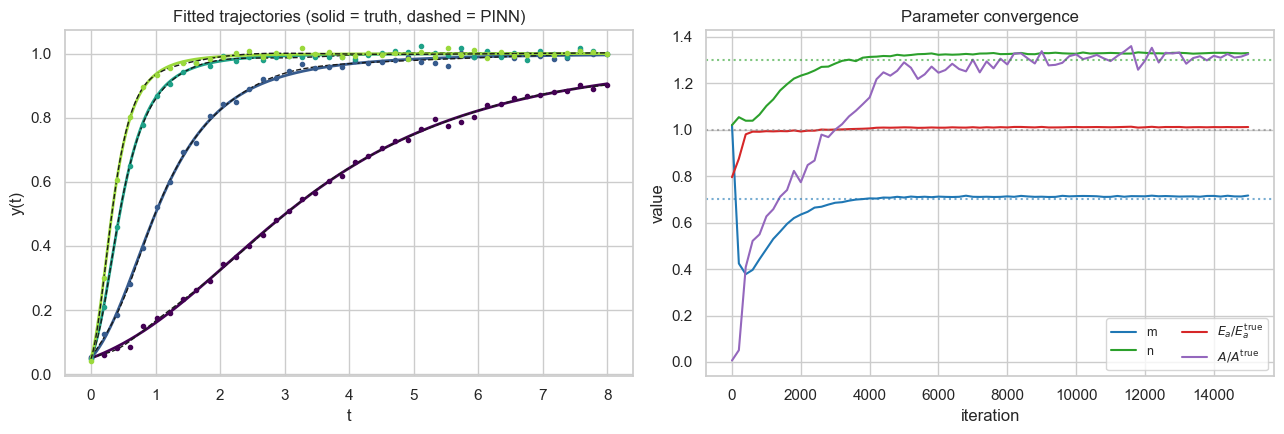

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) fitted trajectories vs truth and data
ax = axes[0]
with torch.no_grad():
    tt = torch.tensor(t_grid, dtype=torch.float32, device=DEVICE).view(-1, 1)
    for c, Tc, net in zip(colors, T_CELSIUS, inv_nets):
        y_fit = net(tt).cpu().numpy()[:, 0]
        ax.plot(t_grid, traj[Tc], "-",  color=c, lw=2)
        ax.plot(t_grid, y_fit,    "--", color="k", lw=1)
        ax.plot(*datasets[Tc], "o", color=c, ms=3)
ax.set_xlabel("t"); ax.set_ylabel("y(t)")
ax.set_title("Fitted trajectories (solid = truth, dashed = PINN)")

# (b) parameter convergence (A, Ea normalised by truth so all quantities are O(1))
ax = axes[1]
its = [h["iter"] for h in hist_arr]
ax.plot(its, [h["m"] for h in hist_arr], label="m", color="tab:blue")
ax.plot(its, [h["n"] for h in hist_arr], label="n", color="tab:green")
ax.plot(its, [h["Ea"] / opt.Ea_true for h in hist_arr], label=r"$E_a/E_a^{\rm true}$", color="tab:red")
ax.plot(its, [h["A"]  / opt.A_true  for h in hist_arr], label=r"$A/A^{\rm true}$",   color="tab:purple")
ax.axhline(opt.m_true, ls=":", color="tab:blue",  alpha=0.6)
ax.axhline(opt.n_true, ls=":", color="tab:green", alpha=0.6)
ax.axhline(1.0,        ls=":", color="grey",       alpha=0.6)
ax.set_xlabel("iteration"); ax.set_ylabel("value")
ax.set_title("Parameter convergence"); ax.legend(ncol=2, fontsize=9)

fig.tight_layout(); plt.show()

## Theoretical parameter correlations

How well *can* the four parameters be disentangled, given this experimental design (these
temperatures, this sampling, this noise level)? This is answered a priori by the **Fisher
information**. Linearising the model around the true parameters, the estimator covariance is

$$\mathrm{Cov}(\hat\theta)\;\approx\;\sigma^2\,(S^\top S)^{-1},
\qquad S_{ij}=\frac{\partial y_i}{\partial \theta_j},$$

where $S$ stacks the sensitivities of every model output $y_i$ (across all temperatures and
sampling times) with respect to $\theta=(A,E_a,m,n)$. We compute $S$ by central finite
differences on the RK4 solution at the *true* parameters, using **relative** ($\partial/\partial\ln\theta_j$)
perturbations so the result is independent of the wildly different parameter scales
($A\sim10^{9}$ vs $m\sim1$). The associated **correlation matrix**

$$\rho_{jk}=\frac{\mathrm{Cov}_{jk}}{\sqrt{\mathrm{Cov}_{jj}\,\mathrm{Cov}_{kk}}}$$

reveals the directions of practical non-identifiability.

Relative standard errors  √diag(Cov):
   A: 10.41%
  Ea: 0.43%
   m: 3.10%
   n: 2.04%

Condition number of the (relative) FIM: 4.30e+05


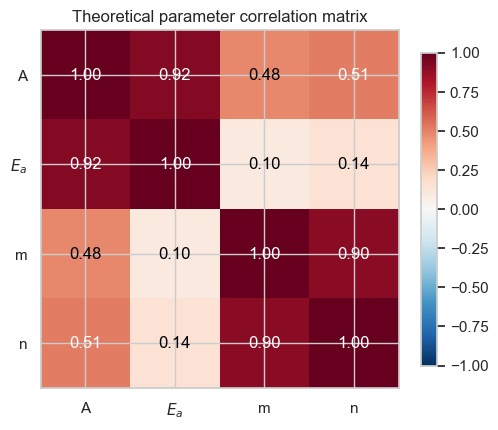

In [17]:
def sb_multi_traj(A, Ea, m, n):
    """Model outputs at the data points, stacked over all temperatures."""
    out = []
    for Tk in T_KELVIN:
        ode_T = SestakBerggren(m, n, arrhenius(Tk, A, Ea))
        out.append(rk4_solve(ode_T.rhs_np, [opt.y0], t_grid)[:, 0][idx_T])
    return np.concatenate(out)

theta  = np.array([opt.A_true, opt.Ea_true, opt.m_true, opt.n_true])
pnames = ["A", r"$E_a$", "m", "n"]
eps_fd = 1e-4

# Relative (d/d ln theta) sensitivities -> scale-invariant analysis
S = np.zeros((N_DATA_T * len(T_CELSIUS), 4))
for j in range(4):
    tp, tm = theta.copy(), theta.copy()
    tp[j] *= (1 + eps_fd); tm[j] *= (1 - eps_fd)
    S[:, j] = (sb_multi_traj(*tp) - sb_multi_traj(*tm)) / (2 * eps_fd)

FIM  = S.T @ S / NOISE_SD**2
Cov  = np.linalg.inv(FIM)
se   = np.sqrt(np.diag(Cov))               # relative standard errors
Corr = Cov / np.outer(se, se)

print("Relative standard errors  √diag(Cov):")
for j in range(4):
    print(f"  {['A','Ea','m','n'][j]:>2}: {se[j]:.2%}")
print(f"\nCondition number of the (relative) FIM: {np.linalg.cond(FIM):.2e}")

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(Corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(4)); ax.set_xticklabels(pnames)
ax.set_yticks(range(4)); ax.set_yticklabels(pnames)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{Corr[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(Corr[i, j]) > 0.5 else "black")
ax.set_title("Theoretical parameter correlation matrix")
fig.colorbar(im, ax=ax, shrink=0.85)
fig.tight_layout(); plt.show()

**Reading the correlation matrix.** Two strong correlations dominate:

- $\rho(A,E_a)\approx 0.9$ — the hallmark **Arrhenius compensation effect**: a larger
  $E_a$ can be offset by a larger pre-exponential $A$ while leaving the fitted rates almost
  unchanged. This is why $A$ carries by far the largest relative standard error even though
  the *rate* itself is pinned down tightly. A finite temperature span only partially breaks
  it; a wider span (or centring on $T_{\mathrm{ref}}$, as we did for optimisation) reduces it.
- $\rho(m,n)\approx 0.9$ — the two reaction orders shape the same sigmoidal profile and so
  trade off against each other.

The exponents are only weakly correlated with the Arrhenius pair, so the temperature sweep
cleanly separates the *kinetic-order* block $(m,n)$ from the *rate* block $(A,E_a)$ — which
is exactly why adding temperatures rescued the identifiability that failed in Case 2.

## A generalized model with a finite lower asymptote

Real reactions often **stop short of completion**, levelling off at a residual amount
$L_0>0$ instead of consuming all the reactant. A flexible description is

$$\frac{dy}{dt} = -\frac{k(T)}{(C_0-L_0)^{\,m+n-1}}\,(C_0-y)^{m}\,(y-L_0)^{n},
\qquad y(t)\xrightarrow[t\to\infty]{}L_0 ,$$

where $y(t)$ is the **remaining reactant**, $C_0$ the upper asymptote (initial amount) and
$L_0<C_0$ the lower asymptote. The minus sign makes $y$ *decay* from $C_0$ down to $L_0$
(both are equilibria of the rate law).

The normalisation $(C_0-L_0)^{m+n-1}$ is not cosmetic. Introducing the **normalised
conversion** $\alpha=\dfrac{C_0-y}{C_0-L_0}\in[0,1]$ collapses the model **exactly** onto the
canonical Šesták–Berggren equation, $\dot\alpha=k(T)\,\alpha^{m}(1-\alpha)^{n}$, so the
kinetics are scale-free in $(C_0-L_0)$. As before $\alpha=0$ (i.e. $y=C_0$) is an unstable
equilibrium, so the data start from a small nucleated value $\alpha(0)=0.05$.

We now treat **both asymptotes as unknown** and recover the full set $(A,E_a,m,n,L_0,C_0)$ by
inversion. Following the request, $C_0$ is **not** imposed as a hard initial condition on the
network — the PINN's value at $t=0$ is left free, and $C_0$ enters purely as a parameter of the
rate law, fitted to the data like the others. Because there are six parameters we use **six
temperatures**. As we will see, freeing $C_0$ has a sharp consequence for identifiability.

C0_true = 1.0   L0_true = 0.2   y0 = 0.960
A_true = 1.746e+09   Ea_true = 50000 J/mol   T_ref = 295.32 K


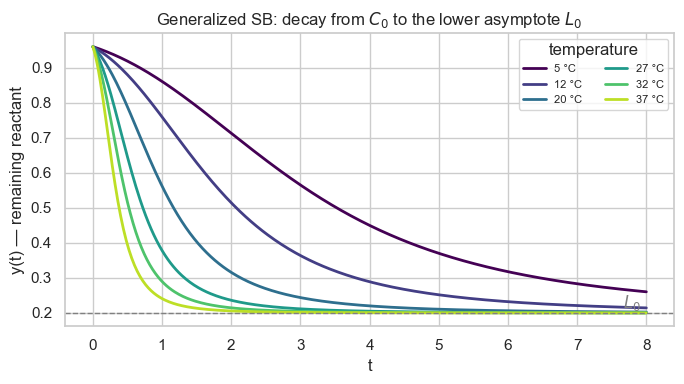

In [18]:
C0_true  = 1.0                       # true upper asymptote (used to generate data)
L0_true  = 0.2                       # true lower asymptote
alpha0   = 0.05                      # nucleation; y(0) = C0 - alpha0*(C0 - L0)
y0_gen   = C0_true - alpha0 * (C0_true - L0_true)

# Six moderate temperatures: a span wide enough for E_a, but with every transition
# well sampled within the horizon (very hot runs decay too fast to resolve).
TG_CELSIUS = np.array([5.0, 12.0, 20.0, 27.0, 32.0, 37.0])
TG_KELVIN  = TG_CELSIUS + 273.15
TG_REF     = float(TG_KELVIN.mean())
A_true_G   = k_ref_true * np.exp(opt.Ea_true / (R_GAS * TG_REF))   # reuse Ea_true, k_ref_true

class GeneralizedSB:
    # dy/dt = -k/(C0-L0)^(m+n-1) * (C0-y)^m * (y-L0)^n     (y decays C0 -> L0)
    def __init__(self, m, n, k, C0, L0):
        self.m, self.n, self.k = float(m), float(n), float(k)
        self.C0, self.L0 = float(C0), float(L0)
    def rhs_np(self, t, z):
        y = min(max(z[0], self.L0 + EPS), self.C0 - EPS)
        return [-self.k / (self.C0 - self.L0)**(self.m + self.n - 1)
                * (self.C0 - y)**self.m * (y - self.L0)**self.n]

t_gen  = np.linspace(0.0, opt.T_h, 400).astype(np.float32)
traj_g = {}
for Tc, Tk in zip(TG_CELSIUS, TG_KELVIN):
    ode_T = GeneralizedSB(opt.m_true, opt.n_true, arrhenius(Tk, A_true_G, opt.Ea_true), C0_true, L0_true)
    traj_g[Tc] = rk4_solve(ode_T.rhs_np, [y0_gen], t_gen)[:, 0]

print(f"C0_true = {C0_true}   L0_true = {L0_true}   y0 = {y0_gen:.3f}")
print(f"A_true = {A_true_G:.3e}   Ea_true = {opt.Ea_true:.0f} J/mol   T_ref = {TG_REF:.2f} K")

colors_g = plt.cm.viridis(np.linspace(0.0, 0.9, len(TG_CELSIUS)))
fig, ax = plt.subplots(figsize=(7, 4))
for c_, Tc in zip(colors_g, TG_CELSIUS):
    ax.plot(t_gen, traj_g[Tc], lw=2, color=c_, label=f"{Tc:.0f} °C")
ax.axhline(L0_true, ls="--", color="grey", lw=1)
ax.text(opt.T_h * 0.99, L0_true + 0.015, "$L_0$", ha="right", color="grey")
ax.set_xlabel("t"); ax.set_ylabel("y(t) — remaining reactant")
ax.legend(title="temperature", ncol=2, fontsize=8)
ax.set_title(r"Generalized SB: decay from $C_0$ to the lower asymptote $L_0$")
fig.tight_layout(); plt.show()

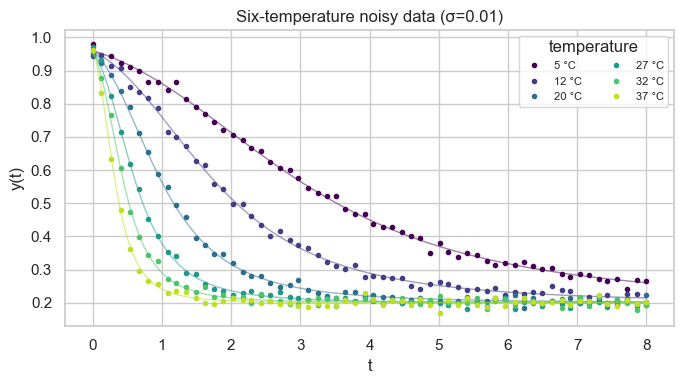

In [19]:
rng_g    = np.random.default_rng(3)
N_DATA_G = 60
idx_g    = np.linspace(0, len(t_gen) - 1, N_DATA_G).astype(int)
datasets_g = {Tc: (t_gen[idx_g], traj_g[Tc][idx_g] + NOISE_SD * rng_g.standard_normal(N_DATA_G))
              for Tc in TG_CELSIUS}

fig, ax = plt.subplots(figsize=(7, 4))
for c, Tc in zip(colors_g, TG_CELSIUS):
    ax.plot(t_gen, traj_g[Tc], "-", color=c, lw=1, alpha=0.5)
    ax.plot(*datasets_g[Tc], "o", color=c, ms=3, label=f"{Tc:.0f} °C")
ax.set_xlabel("t"); ax.set_ylabel("y(t)"); ax.legend(title="temperature", ncol=2, fontsize=8)
ax.set_title(f"Six-temperature noisy data (σ={NOISE_SD})")
fig.tight_layout(); plt.show()

### Joint training routine

One PINN per temperature, sharing the six unknowns $(A,E_a,m,n,L_0,C_0)$. The rate uses the
same centred Arrhenius parametrisation. The asymptotes are kept ordered and physical without
any hard constraint on the networks: the upper one is parametrised as
$C_0=y_{\max}+\mathrm{softplus}(\cdot)$ (so it stays above every observation) and the lower one
as $L_0=C_0\,\sigma(\cdot)\in(0,C_0)$. Both enter the rate law and its normalisation
$(C_0-L_0)^{m+n-1}$ and are fitted jointly with the kinetics.

In [20]:
def solve_inverse_general(
    datasets, temps_K, T_ref, T_h, *,
    Ea_init=40_000.0, kref_init=1.0, mn_init=(1.0, 1.0), L0_frac_init=0.5,
    n_iter=15_000, n_colloc=256, lr_net=2e-3, lr_kin=2e-2, lr_decay=0.9999,
    data_weight=100.0, rec_frq=200, seed=0, verbose=True,
):
    # Joint inverse for the generalized model: recovers A, Ea, m, n, L0 AND C0.
    # C0 is a soft parameter (no hard IC); it stays above the data via a softplus.
    sp = torch.nn.functional.softplus
    torch.manual_seed(seed)
    temps = list(datasets.keys())
    nets = [PINN(PINNConfig(n_vars=1, width=64, depth=4)).to(DEVICE) for _ in temps]

    y_max = max(float(yd.max()) for _, yd in datasets.values())
    y_max_t = torch.tensor(y_max, dtype=torch.float32, device=DEVICE)

    EA_SCALE = 1e4
    log_kref = torch.tensor([np.log(kref_init)], dtype=torch.float32, device=DEVICE, requires_grad=True)
    s_ea     = torch.tensor([Ea_init / EA_SCALE],  dtype=torch.float32, device=DEVICE, requires_grad=True)
    log_m    = torch.tensor([np.log(mn_init[0])],  dtype=torch.float32, device=DEVICE, requires_grad=True)
    log_n    = torch.tensor([np.log(mn_init[1])],  dtype=torch.float32, device=DEVICE, requires_grad=True)
    raw_L0   = torch.tensor([np.log(L0_frac_init / (1 - L0_frac_init))], dtype=torch.float32, device=DEVICE, requires_grad=True)
    raw_C0   = torch.tensor([-1.0], dtype=torch.float32, device=DEVICE, requires_grad=True)  # C0 starts ~y_max+0.3
    kin = [log_kref, s_ea, log_m, log_n, raw_L0, raw_C0]

    net_params = [p for net in nets for p in net.parameters()]
    optimizer = torch.optim.Adam([{"params": net_params, "lr": lr_net},
                                  {"params": kin,        "lr": lr_kin}])
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)

    Tk   = torch.tensor([temps_K[Tc] for Tc in temps], dtype=torch.float32, device=DEVICE)
    invd = 1.0 / Tk - 1.0 / T_ref
    data_t = {Tc: (torch.tensor(td, dtype=torch.float32, device=DEVICE).view(-1, 1),
                   torch.tensor(yd, dtype=torch.float32, device=DEVICE).view(-1, 1))
              for Tc, (td, yd) in datasets.items()}

    def current():
        with torch.no_grad():
            Ea = float(EA_SCALE * s_ea); kref = float(torch.exp(log_kref))
            C0 = float(y_max_t + sp(raw_C0)); L0 = float(C0 * torch.sigmoid(raw_L0))
            return dict(A=kref * np.exp(Ea / (R_GAS * T_ref)), Ea=Ea,
                        m=float(torch.exp(log_m)), n=float(torch.exp(log_n)),
                        L0=L0, C0=C0, kref=kref)

    history = []
    for it in range(n_iter + 1):
        optimizer.zero_grad()
        m, n = torch.exp(log_m), torch.exp(log_n)
        Ea = EA_SCALE * s_ea
        C0 = y_max_t + sp(raw_C0)
        L0 = C0 * torch.sigmoid(raw_L0)
        norm = (C0 - L0) ** (m + n - 1)
        loss = 0.0
        for j, Tc in enumerate(temps):
            k_j = torch.exp(log_kref - (Ea / R_GAS) * invd[j])
            t_col = (torch.rand(n_colloc, 1, device=DEVICE) * T_h).requires_grad_(True)
            y = nets[j](t_col)
            dy = torch.autograd.grad(y.sum(), t_col, create_graph=True)[0]
            yc = torch.maximum(torch.minimum(y, C0 - EPS), L0 + EPS)
            rhs = -k_j / norm * (C0 - yc)**m * (yc - L0)**n
            td, yd = data_t[Tc]
            loss = loss + ((dy - rhs)**2).mean() + data_weight * ((nets[j](td) - yd)**2).mean()
        loss.backward(); optimizer.step(); scheduler.step()

        if it % rec_frq == 0:
            rec = dict(iter=it, loss=loss.item()); rec.update(current())
            history.append(rec)
            if verbose and it % max(1, n_iter // 6) == 0:
                print(f"  iter {it:6d} | loss {loss.item():.3e} | A {rec['A']:.2e}  "
                      f"Ea {rec['Ea']:.0f}  m {rec['m']:.3f}  n {rec['n']:.3f}  "
                      f"L0 {rec['L0']:.3f}  C0 {rec['C0']:.3f}")
    for net in nets:
        net.eval()
    return nets, history, current()

In [21]:
inv_nets_g, hist_g, est_g = solve_inverse_general(
    datasets_g, dict(zip(TG_CELSIUS, TG_KELVIN)), TG_REF, opt.T_h,
    Ea_init=40_000.0, kref_init=1.0, mn_init=(1.0, 1.0), L0_frac_init=0.5,
    n_iter=15_000, n_colloc=256, data_weight=100.0, seed=0,
)

truth_g = dict(A=A_true_G, Ea=opt.Ea_true, m=opt.m_true, n=opt.n_true, L0=L0_true, C0=C0_true)
units_g = dict(A="", Ea=" J/mol", m="", n="", L0="", C0="")

# data-fit quality (RMSE) — should sit at the noise level even when parameters are off
with torch.no_grad():
    sq = []
    for j, Tc in enumerate(TG_CELSIUS):
        td, yd = datasets_g[Tc]
        tt = torch.tensor(td, dtype=torch.float32, device=DEVICE).view(-1, 1)
        sq.append(((inv_nets_g[j](tt).cpu().numpy()[:, 0] - yd) ** 2))
    data_rmse = float(np.sqrt(np.concatenate(sq).mean()))

print("\n--- Generalized model inverse (all six parameters tuned) ---")
for p in ["A", "Ea", "m", "n", "L0", "C0"]:
    rel = abs(est_g[p] - truth_g[p]) / abs(truth_g[p])
    print(f"  {p:>2}: true {truth_g[p]:.3e} | est {est_g[p]:.3e}{units_g[p]}  (rel. err {rel:.1%})")
print(f"\n  rate at T_ref:  true {k_ref_true:.3f} | est {est_g['kref']:.3f}  "
      f"(rel. err {abs(est_g['kref']-k_ref_true)/k_ref_true:.1%})")
print(f"  data-fit RMSE:  {data_rmse:.4f}   (measurement noise σ = {NOISE_SD})")
print("\n  Note: the data are reproduced essentially to the noise floor. Compare that with")
print("  the parameter errors above — m, C0 and the absolute rate are the poorly determined")
print("  ones, sliding along the m-C0 degeneracy exposed by the correlation matrix below.")

  iter      0 | loss 7.881e+01 | A 1.15e+07  Ea 39947  m 1.000  n 1.020  L0 0.647  C0 1.294
  iter   5000 | loss 5.607e-02 | A 2.62e+09  Ea 50575  m 0.880  n 1.384  L0 0.201  C0 1.033
  iter  10000 | loss 5.414e-02 | A 2.44e+09  Ea 50628  m 0.780  n 1.329  L0 0.202  C0 1.017
  iter  15000 | loss 5.349e-02 | A 2.49e+09  Ea 50609  m 0.819  n 1.347  L0 0.201  C0 1.022

--- Generalized model inverse (all six parameters tuned) ---
   A: true 1.746e+09 | est 2.494e+09  (rel. err 42.8%)
  Ea: true 5.000e+04 | est 5.061e+04 J/mol  (rel. err 1.2%)
   m: true 7.000e-01 | est 8.188e-01  (rel. err 17.0%)
   n: true 1.300e+00 | est 1.347e+00  (rel. err 3.6%)
  L0: true 2.000e-01 | est 2.008e-01  (rel. err 0.4%)
  C0: true 1.000e+00 | est 1.022e+00  (rel. err 2.2%)

  rate at T_ref:  true 2.500 | est 2.787  (rel. err 11.5%)
  data-fit RMSE:  0.0093   (measurement noise σ = 0.01)

  Note: the data are reproduced essentially to the noise floor. Compare that with
  the parameter errors above — m, C0 an

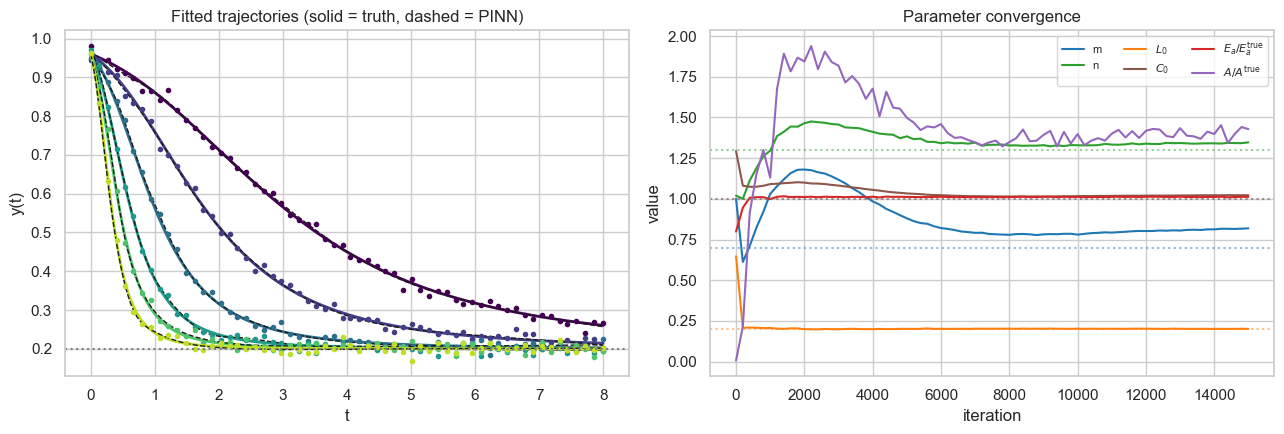

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
with torch.no_grad():
    tt = torch.tensor(t_gen, dtype=torch.float32, device=DEVICE).view(-1, 1)
    for c_, Tc, net in zip(colors_g, TG_CELSIUS, inv_nets_g):
        ax.plot(t_gen, traj_g[Tc], "-",  color=c_, lw=2)
        ax.plot(t_gen, net(tt).cpu().numpy()[:, 0], "--", color="k", lw=1)
        ax.plot(*datasets_g[Tc], "o", color=c_, ms=3)
ax.axhline(L0_true, ls=":", color="grey")
ax.set_xlabel("t"); ax.set_ylabel("y(t)")
ax.set_title("Fitted trajectories (solid = truth, dashed = PINN)")

ax = axes[1]
its = [h["iter"] for h in hist_g]
ax.plot(its, [h["m"]  for h in hist_g], label="m",      color="tab:blue")
ax.plot(its, [h["n"]  for h in hist_g], label="n",      color="tab:green")
ax.plot(its, [h["L0"] for h in hist_g], label=r"$L_0$", color="tab:orange")
ax.plot(its, [h["C0"] for h in hist_g], label=r"$C_0$", color="tab:brown")
ax.plot(its, [h["Ea"] / opt.Ea_true for h in hist_g], label=r"$E_a/E_a^{\rm true}$", color="tab:red")
ax.plot(its, [h["A"]  / A_true_G    for h in hist_g], label=r"$A/A^{\rm true}$",     color="tab:purple")
for v, cl in [(opt.m_true, "tab:blue"), (opt.n_true, "tab:green"), (L0_true, "tab:orange"),
              (C0_true, "tab:brown"), (1.0, "grey")]:
    ax.axhline(v, ls=":", color=cl, alpha=0.5)
ax.set_xlabel("iteration"); ax.set_ylabel("value")
ax.set_title("Parameter convergence"); ax.legend(ncol=3, fontsize=8)
fig.tight_layout(); plt.show()

## Parameter correlations for the generalized model

The same Fisher-information analysis, now over the six-dimensional
$\theta=(A,E_a,m,n,L_0,C_0)$, computed from relative finite-difference sensitivities of the RK4
solution at the true parameters (with the experimental start $y_0$ held fixed) across the
six-temperature design.

Relative standard errors  √diag(Cov):
   A: 13.08%
  Ea: 0.42%
   m: 14.22%
   n: 3.45%
  L0: 0.54%
  C0: 1.92%

Condition number of the (relative) FIM: 1.77e+06
Strongest correlation: rho(m, C0) = 0.979


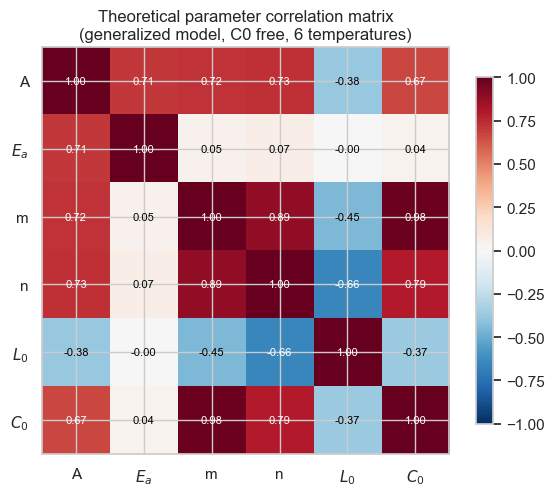

In [23]:
def gsb_multi_traj(A, Ea, m, n, L0, C0):
    out = []
    for Tk in TG_KELVIN:
        ode_T = GeneralizedSB(m, n, arrhenius(Tk, A, Ea), C0, L0)
        out.append(rk4_solve(ode_T.rhs_np, [y0_gen], t_gen)[:, 0][idx_g])
    return np.concatenate(out)

theta_g  = np.array([A_true_G, opt.Ea_true, opt.m_true, opt.n_true, L0_true, C0_true])
pnames_g = ["A", r"$E_a$", "m", "n", r"$L_0$", r"$C_0$"]
eps_fd   = 1e-4

S = np.zeros((N_DATA_G * len(TG_CELSIUS), 6))
for j in range(6):
    tp, tm = theta_g.copy(), theta_g.copy()
    tp[j] *= (1 + eps_fd); tm[j] *= (1 - eps_fd)
    S[:, j] = (gsb_multi_traj(*tp) - gsb_multi_traj(*tm)) / (2 * eps_fd)

FIM  = S.T @ S / NOISE_SD**2
Cov  = np.linalg.inv(FIM)
se   = np.sqrt(np.diag(Cov))
Corr = Cov / np.outer(se, se)

print("Relative standard errors  √diag(Cov):")
for j, nm in enumerate(["A", "Ea", "m", "n", "L0", "C0"]):
    print(f"  {nm:>2}: {se[j]:.2%}")
print(f"\nCondition number of the (relative) FIM: {np.linalg.cond(FIM):.2e}")
print(f"Strongest correlation: rho(m, C0) = {Corr[2, 5]:.3f}")

fig, ax = plt.subplots(figsize=(6.0, 5.0))
im = ax.imshow(Corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(6)); ax.set_xticklabels(pnames_g)
ax.set_yticks(range(6)); ax.set_yticklabels(pnames_g)
for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{Corr[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(Corr[i, j]) > 0.5 else "black", fontsize=8)
ax.set_title("Theoretical parameter correlation matrix\n(generalized model, C0 free, 6 temperatures)")
fig.colorbar(im, ax=ax, shrink=0.85)
fig.tight_layout(); plt.show()

**The cost of freeing $C_0$.** The correlation matrix now contains a near-perfect
$\rho(m,C_0)\approx 0.98$: the upper asymptote and the autocatalytic exponent both govern the
early-time behaviour near $y=C_0$ through the factor $(C_0-y)^m$, so they trade off almost
completely. The consequence is visible above — the PINN reproduces every trajectory to the
noise floor, yet its estimates of $m$, $C_0$ and the absolute rate drift along this degenerate
direction and are individually unreliable (their standard errors balloon accordingly). The
well-conditioned quantities — $E_a$, the reaction order $n$, and the lower asymptote $L_0$
(pinned by the late-time plateau) — remain accurate.

The practical lesson: **$C_0$ should be measured, not fitted**. With $C_0$ fixed at its known
value the same six-temperature design recovers $(A,E_a,m,n,L_0)$ cleanly (the $\rho(m,C_0)$
degeneracy disappears); freeing it converts a well-posed inversion into an ill-conditioned one,
exactly as the Fisher analysis predicts.

## $C_0$ as an initial constraint

The degeneracy above comes from treating $C_0$ as a pure *rate-law* parameter, decoupled from where
the trajectory starts (the experiment start $y_0$ was held fixed while $\theta$ was perturbed). But
$C_0$ also **sets the initial condition**: the run begins at $y_0 = C_0 - \alpha_0(C_0 - L_0)$, just
below the upper asymptote.

If we use $C_0$ as a **hard initial constraint** — start at $y_0(C_0, L_0)$ rather than at a fixed
value — then perturbing $C_0$ moves the start too, so the early data measures $C_0$ *directly*
($\partial y(0)/\partial C_0 \approx 1-\alpha_0$). We recompute the Fisher analysis with $y_0$ tied to
$(C_0, L_0)$; everything else is identical.

*(The start must stay below $C_0$: at $y=C_0$ the factor $(C_0-y)^m$ vanishes — an equilibrium that
stalls the dynamics — so $\alpha_0>0$ is needed and is assumed known.)*

Relative standard errors   (C0 tied to IC  vs  C0 free):
   A:  10.05%   (free:  13.08%)
  Ea:   0.42%   (free:   0.42%)
   m:   3.62%   (free:  14.22%)
   n:   2.30%   (free:   3.45%)
  L0:   0.51%   (free:   0.54%)
  C0:   0.29%   (free:   1.92%)

Condition number: 5.54e+05   (free: 1.77e+06)
rho(m, C0):       -0.585      (free: +0.979)


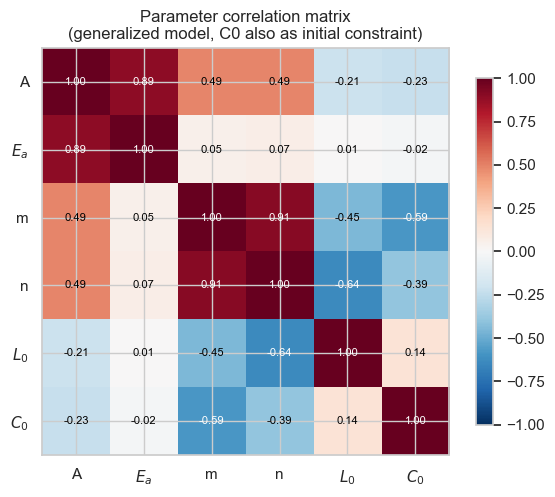

In [25]:
def gsb_multi_traj_ic(A, Ea, m, n, L0, C0):
    # Same model, but C0 also sets the initial condition (hard IC):
    #   y(0) = C0 - alpha0*(C0 - L0)  ->  perturbing C0/L0 moves the start too.
    y0 = C0 - alpha0 * (C0 - L0)
    out = []
    for Tk in TG_KELVIN:
        ode_T = GeneralizedSB(m, n, arrhenius(Tk, A, Ea), C0, L0)
        out.append(rk4_solve(ode_T.rhs_np, [y0], t_gen)[:, 0][idx_g])
    return np.concatenate(out)

S_ic = np.zeros((N_DATA_G * len(TG_CELSIUS), 6))
for j in range(6):
    tp, tm = theta_g.copy(), theta_g.copy()
    tp[j] *= (1 + eps_fd); tm[j] *= (1 - eps_fd)
    S_ic[:, j] = (gsb_multi_traj_ic(*tp) - gsb_multi_traj_ic(*tm)) / (2 * eps_fd)

FIM_ic  = S_ic.T @ S_ic / NOISE_SD**2
Cov_ic  = np.linalg.inv(FIM_ic)
se_ic   = np.sqrt(np.diag(Cov_ic))
Corr_ic = Cov_ic / np.outer(se_ic, se_ic)

print("Relative standard errors   (C0 tied to IC  vs  C0 free):")
for j, nm in enumerate(["A", "Ea", "m", "n", "L0", "C0"]):
    print(f"  {nm:>2}: {se_ic[j]:7.2%}   (free: {se[j]:7.2%})")
print(f"\nCondition number: {np.linalg.cond(FIM_ic):.2e}   (free: {np.linalg.cond(FIM):.2e})")
print(f"rho(m, C0):       {Corr_ic[2, 5]:+.3f}      (free: {Corr[2, 5]:+.3f})")

fig, ax = plt.subplots(figsize=(6.0, 5.0))
im = ax.imshow(Corr_ic, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(6)); ax.set_xticklabels(pnames_g)
ax.set_yticks(range(6)); ax.set_yticklabels(pnames_g)
for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{Corr_ic[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(Corr_ic[i, j]) > 0.5 else "black", fontsize=8)
ax.set_title("Parameter correlation matrix\n(generalized model, C0 also as initial constraint)")
fig.colorbar(im, ax=ax, shrink=0.85)
fig.tight_layout(); plt.show()

## Conclusions

- **Forward.** With the hard-IC parametrisation and a causal time-marching curriculum the
  PINN solves the Šesták–Berggren ODE to high accuracy (matching RK4 to $\sim10^{-3}$),
  while avoiding the spurious $y\equiv0$ equilibrium.
- **Inverse (k known).** Treating $(m,n)$ as trainable variables recovers the reaction
  orders from a few dozen noisy points.
- **Inverse (m, n, k), single trajectory.** Ill-conditioned: the rate law acts through the
  product $k\,y^{m}(1-y)^{n}$, so a whole family of parameters fits one trajectory equally well.
- **Arrhenius temperature sweep.** Tying $k$ to $T$ via $k(T)=A e^{-E_a/RT}$ and fitting
  trajectories at $\{5,20,32,37\}\,^{\circ}\mathrm{C}$ **simultaneously** restores
  identifiability: the joint PINN inverse recovers $E_a$, $m$ and $n$ well, and the *rate*
  (hence $A$) to within its correlation-limited uncertainty.
- **Theoretical correlations.** A Fisher-information analysis exposes the residual structure:
  $A$ and $E_a$ remain strongly correlated (the Arrhenius compensation effect), as do the two
  reaction orders $m$ and $n$ — useful guidance for experimental design (widen the temperature
  range, sample the transition region densely) and for reporting parameter uncertainties.
- **Generalized model with finite asymptotes.** The model
  $\dot y=-k(T)(C_0-y)^m(y-L_0)^n/(C_0-L_0)^{m+n-1}$ maps exactly onto the canonical SB equation
  in $\alpha=(C_0-y)/(C_0-L_0)$. With the upper asymptote $C_0$ **known**, a six-temperature joint
  PINN inverse recovers $(A,E_a,m,n,L_0)$ well, $L_0$ being pinned by the plateau. **Freeing
  $C_0$** as an additional soft parameter introduces a near-perfect degeneracy
  $\rho(m,C_0)\approx0.98$: the data are still fit to the noise floor, but $m$, $C_0$ and the rate
  become individually unidentifiable — a vivid reminder that a good data fit does not imply
  trustworthy parameters, and that identifiability must be checked (e.g. via Fisher information)
  rather than assumed.